<ipython-input-3-14a0105651c4>:48: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, Z, levels=[0], colors='black', linestyles='dashed',
<ipython-input-3-14a0105651c4>:52: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, Z+0.3*np.sin(xx*2), levels=[0], colors='green',
<ipython-input-3-14a0105651c4>:60: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, low_density, levels=[0.3], colors='purple', linestyles=':',


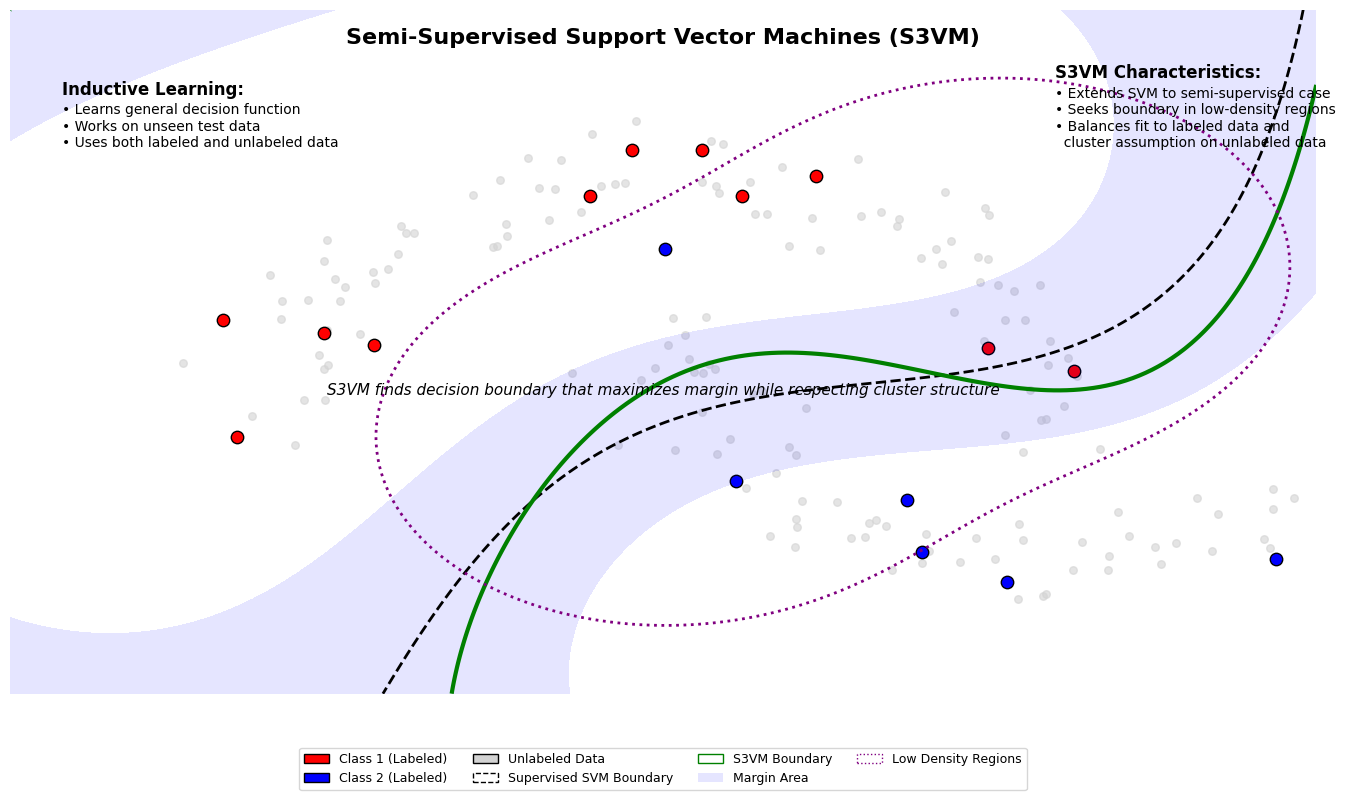

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.datasets import make_moons
from sklearn.svm import SVC

plt.figure(figsize=(14, 8))
ax = plt.gca()
ax.set_xlim(-2, 3)
ax.set_ylim(-2, 2)
ax.axis('off')

# Title
plt.text(0.5, 1.8, 'Semi-Supervised Support Vector Machines (S3VM)',
         fontsize=16, ha='center', weight='bold')

# Generate moon-shaped data
np.random.seed(42)
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)
X = X * 1.5 + np.array([0.5, -0.5])

# Split into labeled and unlabeled
labeled_idx = np.random.choice(200, size=20, replace=False)
unlabeled_idx = np.setdiff1d(np.arange(200), labeled_idx)

# Plot unlabeled data
plt.scatter(X[unlabeled_idx, 0], X[unlabeled_idx, 1],
            c='lightgray', s=30, alpha=0.6, label='Unlabeled Data')

# Plot labeled data
colors = ['red', 'blue']
for i in range(2):
    class_idx = labeled_idx[y[labeled_idx] == i]
    plt.scatter(X[class_idx, 0], X[class_idx, 1],
                c=colors[i], s=80, edgecolor='black',
                label=f'Class {i+1} (Labeled)')

# Train regular SVM (supervised)
svm = SVC(kernel='rbf', C=1.0)
svm.fit(X[labeled_idx], y[labeled_idx])

# Create grid for decision boundaries
xx, yy = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-2, 2, 200))
Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot supervised SVM decision boundary
plt.contour(xx, yy, Z, levels=[0], colors='black', linestyles='dashed',
            linewidths=2, label='Supervised SVM Boundary')

# Plot S3VM boundary (hypothetical better boundary)
plt.contour(xx, yy, Z+0.3*np.sin(xx*2), levels=[0], colors='green',
            linewidths=3, label='S3VM Boundary')

# Highlight margin area
plt.contourf(xx, yy, np.abs(Z), levels=[0, 0.5], colors='blue', alpha=0.1)

# Low-density regions
low_density = np.exp(-(xx-0.5)**2 - (yy+0.5)**2) + np.exp(-(xx-1.8)**2 - (yy-0.5)**2)
plt.contour(xx, yy, low_density, levels=[0.3], colors='purple', linestyles=':',
            linewidths=2, label='Low Density Regions')

# Transductive vs Inductive
plt.text(-1.8, 1.5, 'Inductive Learning:', fontsize=12, weight='bold')
plt.text(-1.8, 1.2, '• Learns general decision function\n'
                    '• Works on unseen test data\n'
                    '• Uses both labeled and unlabeled data', fontsize=10)

# S3VM properties
plt.text(2, 1.6, 'S3VM Characteristics:', fontsize=12, weight='bold')
plt.text(2, 1.2, '• Extends SVM to semi-supervised case\n'
                 '• Seeks boundary in low-density regions\n'
                 '• Balances fit to labeled data and\n'
                 '  cluster assumption on unlabeled data', fontsize=10)

# Legend
legend_elements = [
    Patch(facecolor='red', edgecolor='black', label='Class 1 (Labeled)'),
    Patch(facecolor='blue', edgecolor='black', label='Class 2 (Labeled)'),
    Patch(facecolor='lightgray', edgecolor='black', label='Unlabeled Data'),
    Patch(facecolor='none', edgecolor='black', linestyle='dashed',
          label='Supervised SVM Boundary'),
    Patch(facecolor='none', edgecolor='green', label='S3VM Boundary'),
    Patch(facecolor='blue', alpha=0.1, label='Margin Area'),
    Patch(facecolor='none', edgecolor='purple', linestyle=':',
          label='Low Density Regions')
]

plt.legend(handles=legend_elements, loc='lower center',
           bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=9)

plt.text(0.5, -0.25, 'S3VM finds decision boundary that maximizes margin while respecting cluster structure',
         fontsize=11, ha='center', style='italic')

plt.tight_layout()
plt.show()